In [1]:
%load_ext jupyter_black

In [2]:
from pathlib import Path
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from einops import rearrange, reduce
from unet import SRUNet

# Data Preparation

In [3]:
# create torch data set
class PatchDataSet(Dataset):
    def __init__(self, path: Path):
        self.train_list = list((path / "images").glob("*.tif"))
        self.gt_list = list((path / "gt").glob("*.tif"))

    def __len__(self):
        return len(self.train_list)

    def __getitem__(self, idx: int) -> [torch.Tensor, torch.Tensor]:
        # Read image and gt
        image = rearrange(
            torch.as_tensor(
                np.array(Image.open(self.train_list[idx])), dtype=torch.float32
            ),
            "H W C ->C H W",
        )

        gt = torch.as_tensor(
            np.array(Image.open(self.gt_list[idx])), dtype=torch.float32
        )
        return (image, gt)

In [4]:
class Scaler(torch.nn.Module):
    def __init__(
        self,
        dataset: Dataset,
        mean=[103.2342, 108.9519, 100.1419],
        std=[51.3393, 46.7957, 44.9176],
    ):
        super(Scaler, self).__init__()
        # Compute the number of channels
        image, _ = dataset[0]
        n_channels, height, width = image.shape
        dtype = image.dtype
        device = image.device

        # Init Tensor
        if mean == std == None:
            self.mean_ = torch.nn.Parameter(
                torch.zeros((n_channels,), dtype=dtype, device=device),
                requires_grad=False,
            )
            std_ = torch.zeros_like(self.mean_)

            # Compute Mean
            for image, _ in dataset:
                self.mean_ += reduce(image, "C H W -> C", "mean")
            self.mean_ /= len(dataset)

            # Compute Std
            for image, _ in dataset:
                std_ += reduce(
                    (self.mean_[:, None, None] - image) ** 2, "C H W -> C", "mean"
                )
            std_ /= len(dataset)

            self.std_ = torch.nn.Parameter(torch.sqrt(std_), requires_grad=False)
            self.std_[self.std_ == 0] = 1
        else:
            assert (mean is not None) and (std is not None)
            self.mean_ = torch.nn.Parameter(
                torch.as_tensor(mean, dtype=dtype, device=device).reshape(
                    (n_channels, 1, 1)
                ),
                requires_grad=False,
            )
            self.std_ = torch.nn.Parameter(
                torch.as_tensor(std, dtype=dtype, device=device).reshape(
                    (n_channels, 1, 1)
                ),
                requires_grad=False,
            )

    def __call__(self, X: torch.Tensor) -> torch.Tensor:
        assert X.shape[0] == self.mean_.shape[0]
        return (X - self.mean_) / self.std_

    def inverse_transform(self, X: torch.Tensor) -> torch.Tensor:
        assert X.shape[0] == self.mean_.shape[0]
        return X * self.std_ + self.mean_


class DatasetTransformer(torch.utils.data.Dataset):
    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform

    def __getitem__(self, index):
        img, target = self.base_dataset[index]
        return self.transform(img), target / 255.0

    def __len__(self):
        return len(self.base_dataset)

In [6]:
# Initialize data set and scaler
dataset = PatchDataSet(
    Path("/home/mfauvel/Documents/Data/AerialData/AerialImageDataset/train/crop/")
)
scaler = Scaler(dataset)
scale_dataset = DatasetTransformer(dataset, scaler)
train_dataset, valid_dataset, test_dataset = torch.utils.data.random_split(
    scale_dataset, [0.1, 0.1, 0.8]
)

In [7]:
# Prepare data loader
num_threads = 16  # Loading the dataset is using 4 CPU threads
batch_size = 16  # Using minibatches of 512 samples

train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_threads
)

valid_loader = torch.utils.data.DataLoader(
    dataset=valid_dataset, batch_size=batch_size, shuffle=False, num_workers=num_threads
)

test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_threads
)

/home/mfauvel/miniconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 8, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
# Init model
model = SRUNet(in_channels=3, out_channels=1, depth=3)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_epochs = 50
learning_rate = 0.005
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
train_set_len = len(train_loader)
val_set_len = len(valid_loader)
train_loss, val_loss = [], []
best_loss = 10000000.0
model.to(device)

for epoch in range(n_epochs):
    model.train()
    accu = 0.0

    for X_, y_ in train_loader:
        X_ = X_.to(device)
        y_ = y_.to(device)
        # Forward pass
        y_hat = model(X_)
        loss = loss_fn(y_hat, y_.unsqueeze(1))
        accu += loss.item()

        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    train_loss.append(accu / train_set_len)

    # Validation - no gradient & eval mode
    model.eval()
    accu = 0.0
    with torch.no_grad():
        for X_, y_ in valid_loader:
            X_ = X_.to(device)
            y_ = y_.to(device)
            # Forward pass
            y_hat = model(X_)
            loss = loss_fn(y_hat, y_.unsqueeze(1))
            accu += loss.item()
        val_loss.append(accu / val_set_len)
        if best_loss > val_loss[-1]:
            best_loss = val_loss[-1]
            torch.save(model.state_dict(), "best_model.pt")
    print(f"Train_loss: {train_loss[-1]} and Val_loss: {val_loss[-1]}")

In [ ]:
y_.unsqueeze(1).shape

In [ ]:
print(train_loss)

# Garbage

In [9]:
model = SRUNet(in_channels=3, out_channels=1)
model.load_state_dict(
    torch.load("best_model.pt", weights_only=True, map_location=torch.device("cpu"))
)

<All keys matched successfully>

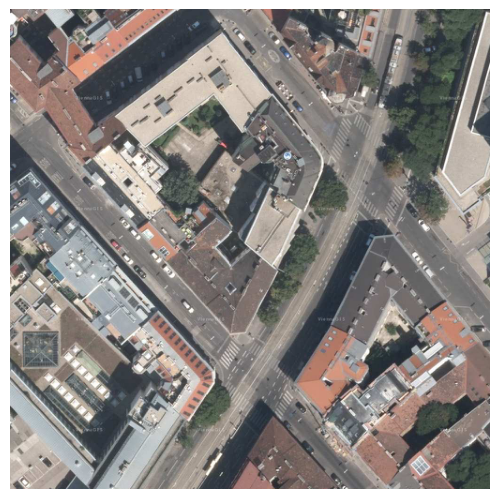

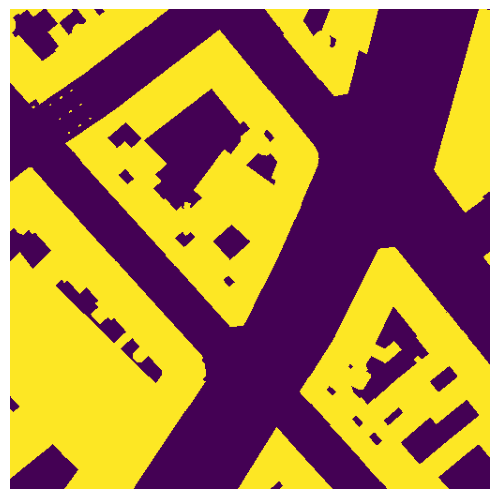

In [23]:
import matplotlib.pyplot as plt

X, Y = train_dataset[1000]
ax = plt.axes([0, 0, 1, 1], frameon=False)
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.autoscale(tight=True)
plt.imshow(rearrange(scaler.inverse_transform(X).to(torch.int), "C H W -> H W C"))
plt.savefig("im_unet.png")
plt.figure()
ax = plt.axes([0, 0, 1, 1], frameon=False)
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.imshow(Y)
plt.savefig("gt_unet.png")

In [11]:
Y.max()

tensor(1.)

/tmp/ipykernel_61000/1757195856.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


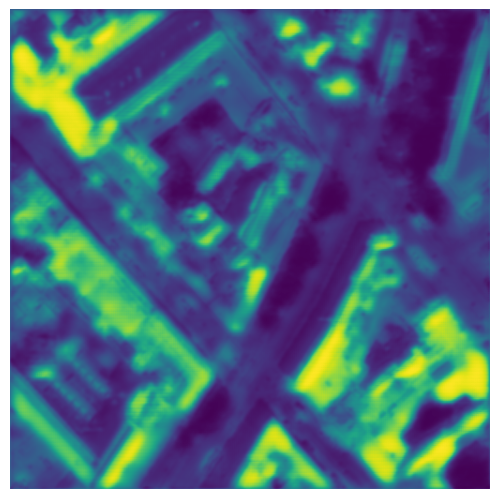

In [69]:
Zl = model(X[None, ...])
Z = torch.sigmoid(model(X[None, ...].to("cpu")))
ax = plt.axes([0, 0, 1, 1], frameon=False)

ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.imshow(Z[0, 0, ...].cpu().detach().numpy())
plt.tight_layout()
plt.savefig("pred_unet.png")

In [64]:
class DiceLoss(nn.Module):
    def __init__(self, ignore_index=255, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.ignore_index = ignore_index
        self.smooth = smooth

    def forward(self, input, target):
        assert input.ndim == 2
        assert input.shape == target.shape
        input = torch.sigmoid(input)
        intersection = (input * target).sum()
        dice = (2.0 * intersection + self.smooth) / (
            input.sum() + target.sum() + self.smooth
        )
        return torch.mean(1 - dice)


class JaccardLoss(nn.Module):
    def __init__(self, ignore_index=255, smooth=1.0):
        super(JaccardLoss, self).__init__()
        self.ignore_index = ignore_index
        self.smooth = smooth

    def forward(self, input, target):
        assert input.ndim == 2
        assert input.shape == target.shape
        input = torch.sigmoid(input)
        intersection = (input * target).sum()
        union = (input + target).sum() - intersection
        IoU = (intersection + self.smooth) / (union + self.smooth)
        return torch.mean(1 - IoU)

In [65]:
nle = nn.BCEWithLogitsLoss()
dice = DiceLoss()
jaccard = JaccardLoss()

In [66]:
nle(Zl, Y[None, None, ...])

tensor(0.5972, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)

In [67]:
dice(Zl.squeeze(), Y)

tensor(0.4398, grad_fn=<MeanBackward0>)

In [68]:
jaccard(Zl.squeeze(), Y)

tensor(0.6109, grad_fn=<MeanBackward0>)